In [1]:
!pip install opencv-python numpy matplotlib

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
nama_file = "dean.jpg"

if not Path(nama_file).exists():
    raise FileNotFoundError(
        f"File '{nama_file}' tidak ditemukan. "
        "Pastikan foto berada dalam folder yang sama dengan notebook."
    )

citra_bgr = cv2.imread(nama_file)

if citra_bgr is None:
    raise ValueError("Gambar gagal dibaca. Periksa nama atau format file.")

# Konversi warna BGR ke RGB
citra_rgb = cv2.cvtColor(citra_bgr, cv2.COLOR_BGR2RGB)

print("Ukuran citra:", citra_bgr.shape)

Ukuran citra: (1280, 960, 3)


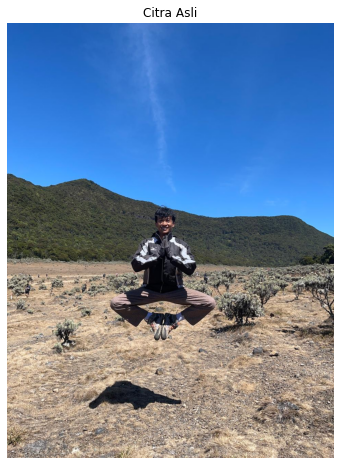

In [4]:
plt.figure(figsize=(6, 8))
plt.imshow(citra_rgb)
plt.title("Citra Asli")
plt.axis("off")
plt.show()

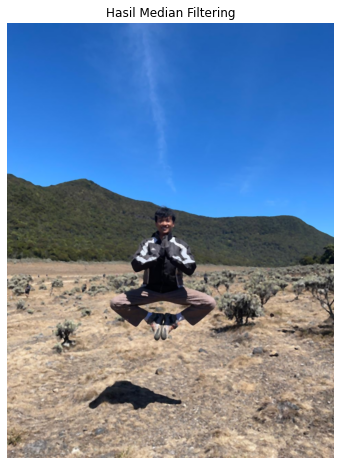

In [5]:
ukuran_kernel_median = 5

hasil_median_bgr = cv2.medianBlur(
    citra_bgr,
    ukuran_kernel_median
)

hasil_median_rgb = cv2.cvtColor(
    hasil_median_bgr,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(6, 8))
plt.imshow(hasil_median_rgb)
plt.title("Hasil Median Filtering")
plt.axis("off")
plt.show()

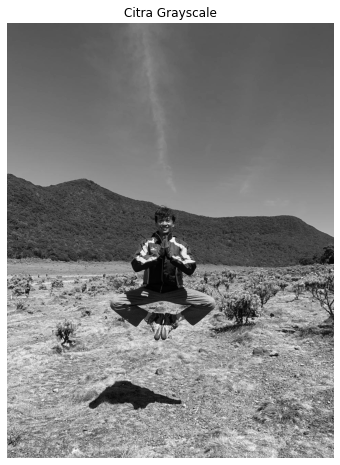

In [6]:
citra_gray = cv2.cvtColor(
    citra_bgr,
    cv2.COLOR_BGR2GRAY
)

plt.figure(figsize=(6, 8))
plt.imshow(citra_gray, cmap="gray")
plt.title("Citra Grayscale")
plt.axis("off")
plt.show()

In [7]:
def mean_filter_manual(citra, ukuran_kernel=5):
    
    # Memastikan ukuran kernel ganjil dan positif
    if ukuran_kernel < 1 or ukuran_kernel % 2 == 0:
        raise ValueError(
            "Ukuran kernel harus berupa bilangan ganjil positif."
        )

    # Menentukan padding
    padding = ukuran_kernel // 2

    # Menambahkan padding pada tepi citra
    citra_padding = np.pad(
        citra,
        pad_width=padding,
        mode="edge"
    )

    # Membuat array kosong untuk hasil filtering
    hasil = np.zeros_like(citra, dtype=np.uint8)

    # Mengambil tinggi dan lebar citra
    tinggi, lebar = citra.shape

    # Menghitung jumlah piksel dalam kernel
    jumlah_piksel_kernel = ukuran_kernel * ukuran_kernel

    # Memproses setiap piksel
    for baris in range(tinggi):
        for kolom in range(lebar):

            # Mengambil area sesuai ukuran kernel
            area_kernel = citra_padding[
                baris:baris + ukuran_kernel,
                kolom:kolom + ukuran_kernel
            ]

            # Menjumlahkan nilai piksel dalam area kernel
            jumlah_nilai = np.sum(
                area_kernel,
                dtype=np.uint32
            )

            # Menghitung rata-rata
            nilai_mean = jumlah_nilai / jumlah_piksel_kernel

            # Menyimpan hasil ke citra baru
            hasil[baris, kolom] = np.uint8(
                np.clip(round(nilai_mean), 0, 255)
            )

    return hasil

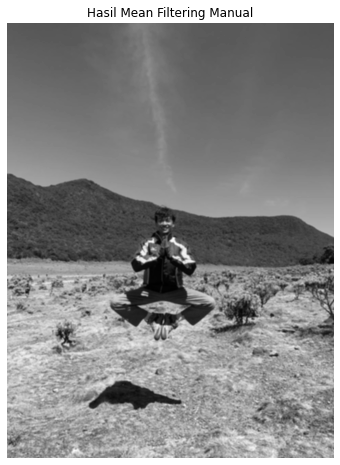

In [8]:
ukuran_kernel_mean = 5

hasil_mean = mean_filter_manual(
    citra_gray,
    ukuran_kernel_mean
)

plt.figure(figsize=(6, 8))
plt.imshow(hasil_mean, cmap="gray")
plt.title("Hasil Mean Filtering Manual")
plt.axis("off")
plt.show()

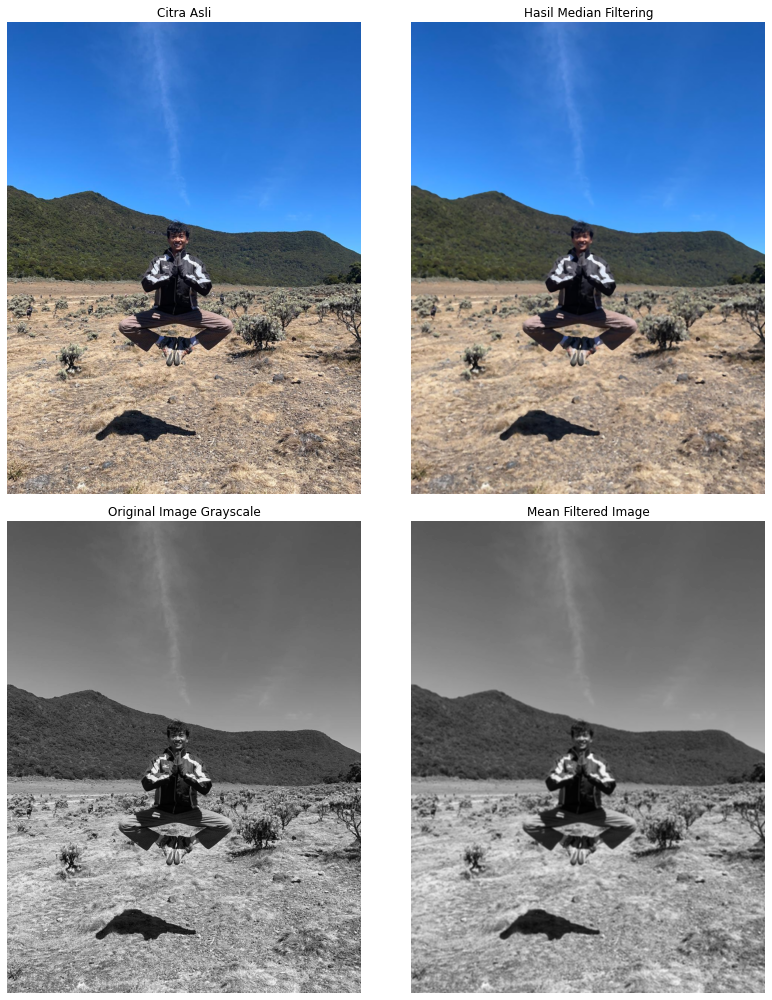

In [9]:
plt.figure(figsize=(12, 14))

plt.subplot(2, 2, 1)
plt.imshow(citra_rgb)
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(hasil_median_rgb)
plt.title("Hasil Median Filtering")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(citra_gray, cmap="gray")
plt.title("Original Image Grayscale")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(hasil_mean, cmap="gray")
plt.title("Mean Filtered Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
cv2.imwrite(
    "hasil_median_filtering.jpg",
    hasil_median_bgr
)

cv2.imwrite(
    "citra_grayscale.jpg",
    citra_gray
)

cv2.imwrite(
    "hasil_mean_filtering_manual.jpg",
    hasil_mean
)

print("Semua hasil berhasil disimpan.")

Semua hasil berhasil disimpan.


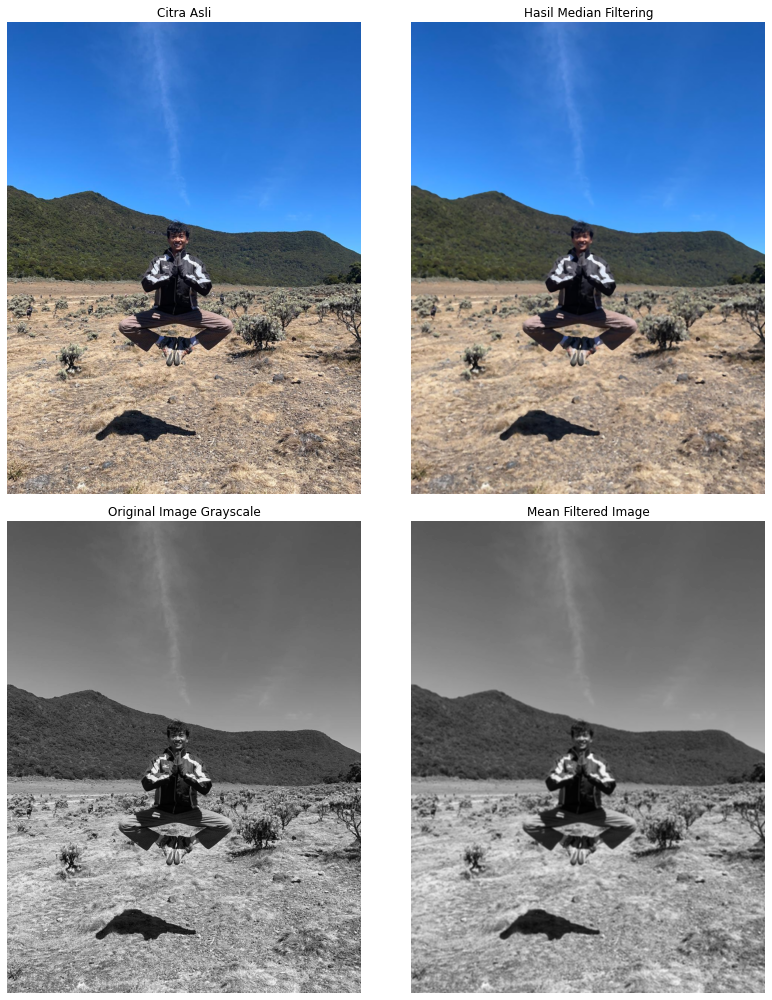

Gambar perbandingan berhasil disimpan.


In [11]:
plt.figure(figsize=(12, 14))

plt.subplot(2, 2, 1)
plt.imshow(citra_rgb)
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(hasil_median_rgb)
plt.title("Hasil Median Filtering")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(citra_gray, cmap="gray")
plt.title("Original Image Grayscale")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(hasil_mean, cmap="gray")
plt.title("Mean Filtered Image")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "perbandingan_filtering.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gambar perbandingan berhasil disimpan.")